<h1 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Word Embedding Intuition</b>
</h1>
<div style="font-family:'Times New Roman';">
A network cannot take words, it needs numbers. The obvious way is one hot, but that throws away every bit of meaning. An embedding is a short dense vector per word, learnt from data, where words used in similar places end up close to each other.
</div>

## one hot, and why it is not enough

one hot gives every word its own column. two problems:

1. the vector is as long as the vocabulary, 50000 words means a 50000 long vector with one 1 in it
2. every pair of diffrent words is exactly equally far apart, so `cat` and `dog` are as unrelated as `cat` and `democracy`

In [1]:
import numpy as np
import matplotlib.pyplot as plt

vocab = ['cat', 'dog', 'car', 'bus']

def one_hot(word):
    v = np.zeros(len(vocab))
    v[vocab.index(word)] = 1
    return v

for w in vocab:
    print(w.ljust(4), one_hot(w))

cat  [1. 0. 0. 0.]
dog  [0. 1. 0. 0.]
car  [0. 0. 1. 0.]
bus  [0. 0. 0. 1.]


In [2]:
print("cat . dog =", one_hot('cat') @ one_hot('dog'))
print("cat . car =", one_hot('cat') @ one_hot('car'))
print("every pair gives 0, so one hot says nothing about meaning")

cat . dog = 0.0
cat . car = 0.0
every pair gives 0, so one hot says nothing about meaning


## dense vectors, made by hand

suppose instead each word is 3 numbers that mean something, say how animal it is, how machine it is, and how big it is. now the numbers themselves carry information.

In [11]:
#                animal  machine  big
vecs = {
    'cat'  : np.array([0.9,   0.0,   0.2]),
    'dog'  : np.array([0.9,   0.1,   0.4]),
    'lion' : np.array([0.95,  0.0,   0.8]),
    'car'  : np.array([0.0,   0.9,   0.6]),
    'bus'  : np.array([0.0,   0.95,  0.9]),
}

def cosine(a, b):
    return a @ b / (np.linalg.norm(a) * np.linalg.norm(b))

print("cat  vs dog  :", round(cosine(vecs['cat'], vecs['dog']), 3))
print("cat  vs lion :", round(cosine(vecs['cat'], vecs['lion']), 3))
print("cat  vs car  :", round(cosine(vecs['cat'], vecs['car']), 3))
print("car  vs bus  :", round(cosine(vecs['car'], vecs['bus']), 3))

cat  vs dog  : 0.975
cat  vs lion : 0.886
cat  vs car  : 0.12
car  vs bus  : 0.986


cosine similarity is used instead of plain distance because only the direction matters, not how long the vector is.

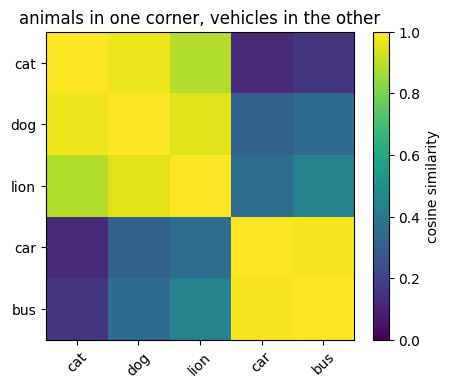

In [4]:
words = list(vecs)
M = np.array([vecs[w] for w in words])
sim = np.array([[cosine(a, b) for b in M] for a in M])

plt.figure(figsize=(5,4))
plt.imshow(sim, cmap='viridis', vmin=0, vmax=1)
plt.xticks(range(len(words)), words, rotation=45)
plt.yticks(range(len(words)), words)
plt.colorbar(label='cosine similarity')
plt.title('animals in one corner, vehicles in the other')
plt.show()

## the real question

nobody hand writes these numbers for 50000 words. so where do they come from?

**the distributional idea :** a word is defined by the words around it. if two words keep showing up in the same kind of context then they probably mean something similar. so the context can be used as the training signal, and no labels are needed.

## counting contexts, on a tiny corpus

In [5]:
corpus = [
    "the cat sat on the mat",
    "the dog sat on the mat",
    "the cat drank the milk",
    "the dog drank the water",
    "i drove the car to work",
    "i drove the bus to work",
]

tokens = [s.split() for s in corpus]
vocab = sorted(set(w for s in tokens for w in s))
idx = {w: i for i, w in enumerate(vocab)}
print(len(vocab), "words :", vocab)

15 words : ['bus', 'car', 'cat', 'dog', 'drank', 'drove', 'i', 'mat', 'milk', 'on', 'sat', 'the', 'to', 'water', 'work']


In [6]:
# how many times does word j appear within 2 words of word i
C = np.zeros((len(vocab), len(vocab)))
window = 2

for s in tokens:
    ids = [idx[w] for w in s]
    for i, w in enumerate(ids):
        for j in range(max(0, i-window), min(len(ids), i+window+1)):
            if i != j:
                C[w, ids[j]] += 1

print("row for 'cat' :")
for w, v in zip(vocab, C[idx['cat']]):
    if v > 0:
        print("  ", w.ljust(6), int(v))

row for 'cat' :
   drank  1
   on     1
   sat    1
   the    3


each row of this matrix is already a vector for that word. its long and mostly zeros, but the meaning is in there. checking with cosine:

In [7]:
def sim_words(a, b):
    return round(cosine(C[idx[a]], C[idx[b]]), 3)

print("cat  vs dog  :", sim_words('cat', 'dog'))
print("car  vs bus  :", sim_words('car', 'bus'))
print("cat  vs car  :", sim_words('cat', 'car'))
print("sat  vs drank:", sim_words('sat', 'drank'))

cat  vs dog  : 1.0
car  vs bus  : 1.0
cat  vs car  : 0.433
sat  vs drank: 0.858


cat and dog come out similar without anyone saying they are both animals. they just appear in the same slots, after `the` and before `sat` or `drank`.

## squeezing it down

the count matrix is `vocab x vocab` wich is huge and mostly zeros. SVD can compress each row into a few numbers, and those few numbers are the embedding.

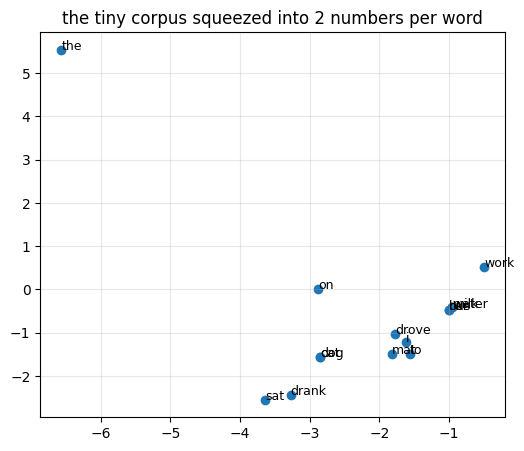

In [9]:
U, S, Vt = np.linalg.svd(C)
E = U[:, :2] * S[:2]        # 2d embedding

plt.figure(figsize=(6,5))
plt.scatter(E[:,0], E[:,1])
for w in vocab:
    plt.annotate(w, (E[idx[w],0], E[idx[w],1]), fontsize=9)
plt.title('the tiny corpus squeezed into 2 numbers per word')
plt.grid(alpha=.3)
plt.show()

on 6 sentences this is not going to be impressive, but the machinery is exactly what notebook 02 does on a real corpus.

### recap

- one hot is long and says nothing about similarity
- an embedding is short, dense, and similar words point in similar directions
- the training signal is the context, no labels needed
- counting contexts and then compressing with SVD is the old way (notebook 02), predicting the context with a network is the word2vec way (notebook 03)